In [2]:
# 데이터 수집 (가져오기)
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])

# Step 1~2. StandardScaler — 스케일 , k-NN 회귀

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 데이터 준비 (교재 농어 데이터)
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

# sklearn 입력 형태 맞춤
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

# 스케일링
ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled = ss.transform(test_input)

# kNN
knr = KNeighborsRegressor()
knr.fit(train_scaled, train_target)

print("test R²:", knr.score(test_scaled, test_target))    # 0.9928
print("MAE:", mean_absolute_error(test_target, knr.predict(test_scaled)))  # 약 19g

test R²: 0.992809406101064
MAE: 19.157142857142862


# Step 3. 선형 회귀 + MSE + 경사 하강법

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.coef_)       # [39.02]  ← 길이 1cm 증가 = 무게 39g 증가
print(lr.intercept_)  # -709.02
print(lr.predict([[50]]))  # [1241.84]

print("train R²:", lr.score(train_input, train_target))  # 0.9398
print("test R²:",  lr.score(test_input, test_target))    # 0.8248

[39.01714496]
-709.0186449535474
[1241.83860323]
train R²: 0.9398463339976041
test R²: 0.824750312331356


# Step 4. 다항 회귀 + 과적합 체험

In [12]:
# x → [x², x]
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly  = np.column_stack((test_input ** 2, test_input))

lr2 = LinearRegression()
lr2.fit(train_poly, train_target)
print("train R²:", lr2.score(train_poly, train_target))  # 0.9707
print("test R²:",  lr2.score(test_poly, test_target))    # 0.9776  ← 선형보다 향상!

train R²: 0.9706807451768623
test R²: 0.9775935108325122


In [13]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

perch_full = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/perch_full.csv')
train_i, test_i, train_t, test_t = train_test_split(perch_full, perch_weight, random_state=42)

poly = PolynomialFeatures(include_bias=False)
poly.fit(train_i)
train_poly = poly.transform(train_i)
test_poly  = poly.transform(test_i)   # test에는 transform만!

print(train_poly.shape)  # (42, 9)

(42, 9)


In [14]:
poly5 = PolynomialFeatures(degree=5, include_bias=False)
poly5.fit(train_i)
train_poly5 = poly5.transform(train_i)
test_poly5  = poly5.transform(test_i)
print(train_poly5.shape)  # (42, 55)

lr.fit(train_poly5, train_t)
print("train R²:", lr.score(train_poly5, train_t))  # 1.0000  ← 과적합!
print("test R²:",  lr.score(test_poly5, test_t))    # -144.4  ← 폭망!

(42, 55)
train R²: 0.9999999999997232
test R²: -144.40564483377855


# Step 5. Ridge / Lasso

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ss = StandardScaler()
train_scaled = ss.fit_transform(train_poly5)
test_scaled  = ss.transform(test_poly5)

ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_t)
print("train R²:", ridge.score(train_scaled, train_t))  # 0.9904
print("test R²:",  ridge.score(test_scaled, test_t))    # 0.9828  ← -144에서 회복!

train R²: 0.9903815817570367
test R²: 0.9827976465386928


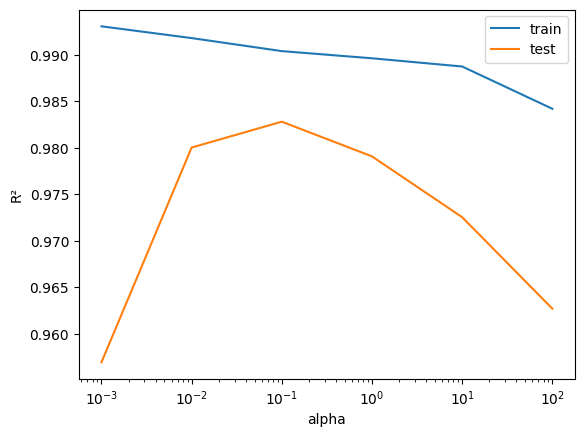

In [16]:
import matplotlib.pyplot as plt

train_score, test_score = [], []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_t)
    train_score.append(ridge.score(train_scaled, train_t))
    test_score.append(ridge.score(test_scaled, test_t))

plt.plot(alpha_list, train_score, label='train')
plt.plot(alpha_list, test_score,  label='test')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R²')
plt.legend()
plt.show()

In [17]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1, max_iter=10000)
lasso.fit(train_scaled, train_t)
print("train R²:", lasso.score(train_scaled, train_t))  # 0.9898
print("test R²:",  lasso.score(test_scaled, test_t))    # 0.9801
print("0인 계수 수:", np.sum(lasso.coef_ == 0))         # 40~47 (자동 특성 선택)

train R²: 0.9898116789062786
test R²: 0.9801844137326112
0인 계수 수: 47
